In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

months = pd.date_range(start="2022-01-01", periods=24, freq="ME")
states = ["Lagos", "Abuja", "Kano", "Rivers", "Oyo"]

rows = []
for state in states:
    for month in months:
        rows.append({
            "date": month,
            "state": state,
            "infection_count": np.random.poisson(
                lam=50 + (20 if state in ["Lagos", "Kano"] else 0)
            ),
            "hospitalised": np.random.poisson(lam=10),
            "recovered": np.random.poisson(lam=40),
            "deaths": np.random.poisson(lam=3),
            "temperature_c": np.random.normal(28, 3, 1)[0].round(1),
            "rainfall_mm": np.random.exponential(scale=80, size=1)[0].round(1),
        })

df = pd.DataFrame(rows)
print(df.shape)
print(df.head(50))

(120, 8)
         date  state  infection_count  hospitalised  recovered  deaths  \
0  2022-01-31  Lagos               67            12         33       2   
1  2022-02-28  Lagos               65             9         42       2   
2  2022-03-31  Lagos               62            11         42       3   
3  2022-04-30  Lagos               68            10         50       4   
4  2022-05-31  Lagos               82            15         34       2   
5  2022-06-30  Lagos               71            13         34       4   
6  2022-07-31  Lagos               58            11         28       5   
7  2022-08-31  Lagos               77            10         36       4   
8  2022-09-30  Lagos               65            13         49       3   
9  2022-10-31  Lagos               80            10         34       4   
10 2022-11-30  Lagos               63             8         40       3   
11 2022-12-31  Lagos               74             7         37       2   
12 2023-01-31  Lagos         

In [4]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             120 non-null    datetime64[ns]
 1   state            120 non-null    object        
 2   infection_count  120 non-null    int64         
 3   hospitalised     120 non-null    int64         
 4   recovered        120 non-null    int64         
 5   deaths           120 non-null    int64         
 6   temperature_c    120 non-null    float64       
 7   rainfall_mm      120 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 7.6+ KB


,date,infection_count,hospitalised,recovered,deaths,temperature_c,rainfall_mm
count,120,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,2023-01-14 10:00:00,58.075000,10.116667,40.166667,2.858333,28.007500,92.061667
min,2022-01-31 00:00:00,32.000000,3.000000,24.000000,0.000000,18.300000,0.400000
25%,2022-07-23 06:00:00,48.000000,8.000000,35.000000,1.000000,26.175000,22.875000
50%,2023-01-15 12:00:00,57.000000,10.000000,40.000000,3.000000,28.000000,60.400000
75%,2023-07-07 18:00:00,67.000000,12.000000,44.250000,4.000000,29.725000,139.950000
max,2023-12-31 00:00:00,86.000000,16.000000,57.000000,8.000000,35.900000,391.300000
std,NaN,12.046941,2.823025,6.650120,1.740742,2.997342,93.121706


In [5]:
df["mortality_rate"] = (df["deaths"] / df["infection_count"]) * 100
df["recovery_rate"] = (df["recovered"] / df["infection_count"]) * 100
df.head()

,date,state,infection_count,hospitalised,recovered,deaths,temperature_c,rainfall_mm,mortality_rate,recovery_rate
0,2022-01-31,Lagos,67,12,33,2,26.3,16.2,2.985075,49.253731
1,2022-02-28,Lagos,65,9,42,2,26.4,123.0,3.076923,64.615385
2,2022-03-31,Lagos,62,11,42,3,26.2,92.2,4.838710,67.741935
3,2022-04-30,Lagos,68,10,50,4,27.1,279.4,5.882353,73.529412
4,2022-05-31,Lagos,82,15,34,2,26.6,26.4,2.439024,41.463415


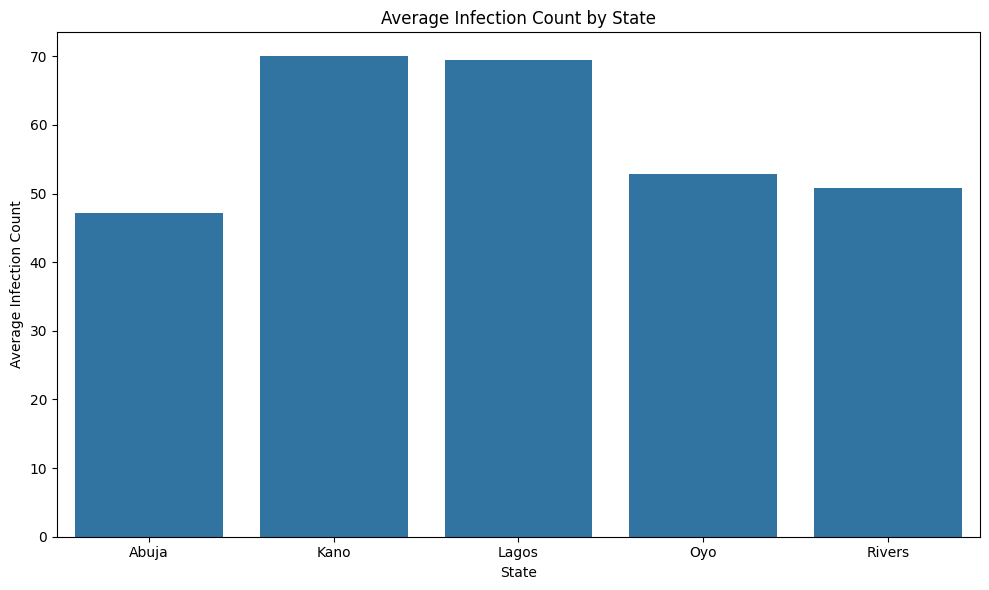

In [6]:
avg_infection_count = df.groupby("state")["infection_count"].mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_infection_count.index, y=avg_infection_count)
plt.title("Average Infection Count by State")
plt.xlabel("State")
plt.ylabel("Average Infection Count")
plt.tight_layout()
plt.show()

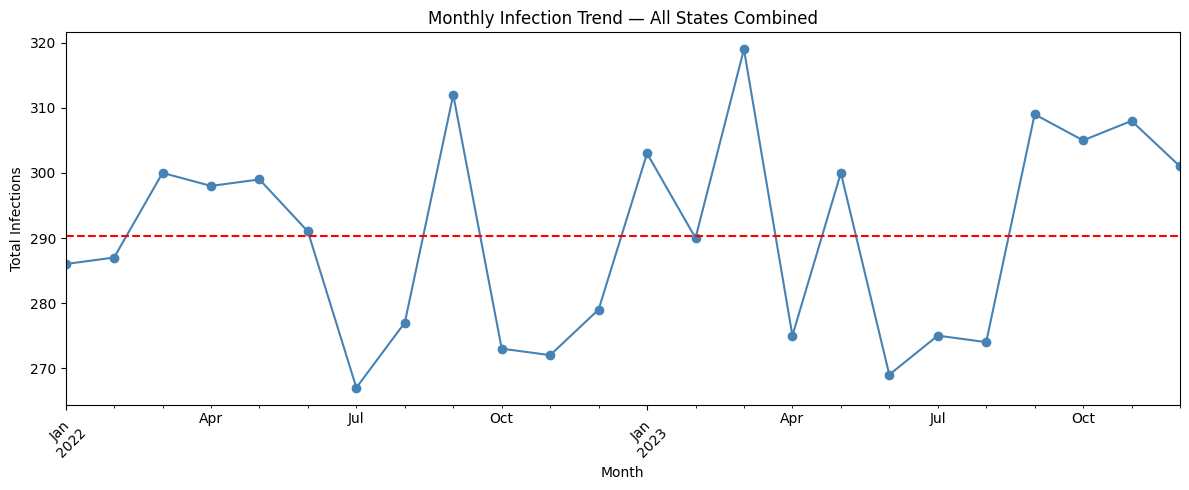

In [7]:
monthly_infection = df.groupby("date")["infection_count"].sum()
plt.figure(figsize=(12, 5))
monthly_infection.plot(kind="line", marker="o", color="steelblue")
plt.axhline(y=monthly_infection.mean(), color="red", linestyle="--")
plt.title("Monthly Infection Trend — All States Combined")
plt.xlabel("Month")
plt.ylabel("Total Infections")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
pearson_corr, pearson_p = stats.pearsonr(df["rainfall_mm"], df["infection_count"])
spearman_corr, spearman_p = stats.spearmanr(df["rainfall_mm"], df["infection_count"])

print(f"Pearson Correlation: {pearson_corr:.2f}, p-value: {pearson_p:.4f}")
print(f"Spearman Correlation: {spearman_corr:.2f}, p-value: {spearman_p:.4f}")


Pearson Correlation: -0.04, p-value: 0.6768
Spearman Correlation: -0.08, p-value: 0.4125


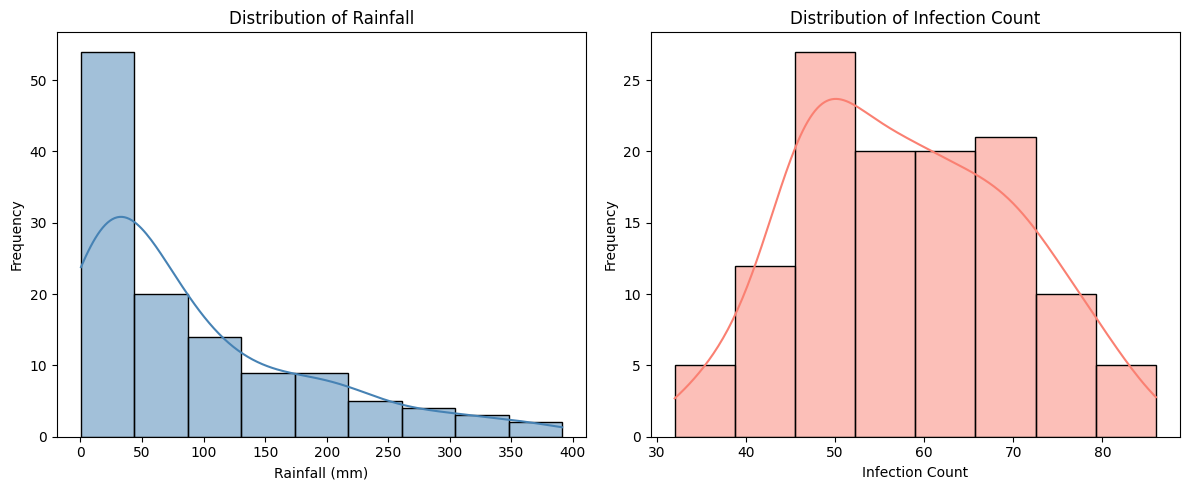

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["rainfall_mm"], ax=axes[0], kde=True, color="steelblue")
axes[0].set_title("Distribution of Rainfall")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Frequency")

sns.histplot(df["infection_count"], ax=axes[1], kde=True, color="salmon")
axes[1].set_title("Distribution of Infection Count")
axes[1].set_xlabel("Infection Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

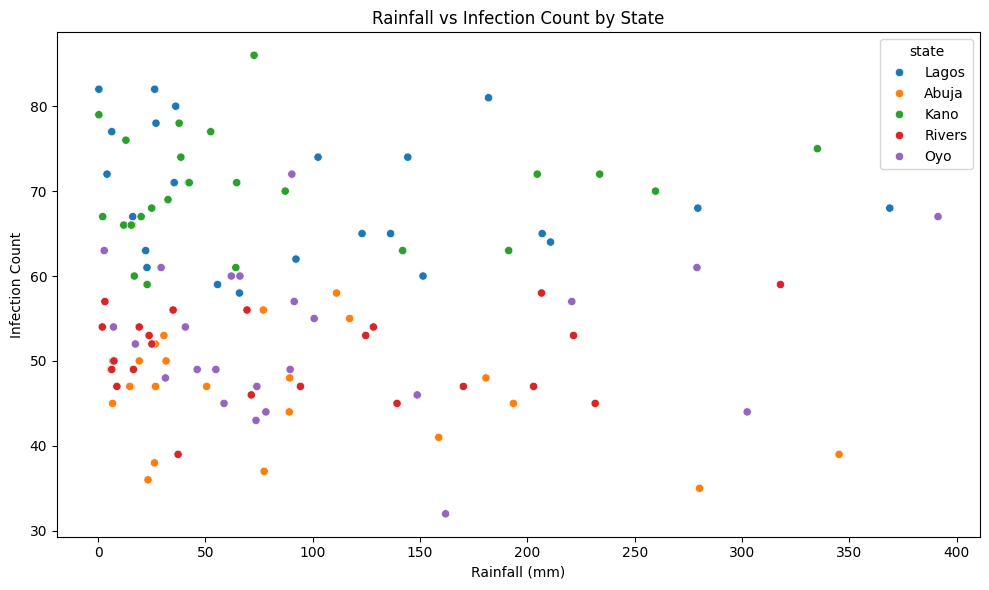

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="rainfall_mm", y="infection_count", hue="state")
plt.title("Rainfall vs Infection Count by State")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Infection Count")
plt.tight_layout()
plt.show()

In [11]:
from scipy import stats

Lagos_mortality = df[df["state"] == "Lagos"]["mortality_rate"]
Kano_mortality = df[df["state"] == "Kano"]["mortality_rate"] # Corrected 'kano' to 'Kano'

t_stat, p_value = stats.ttest_ind(Lagos_mortality, Kano_mortality)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 2.9776
P-value: 0.0046


In [12]:
df.head()

,date,state,infection_count,hospitalised,recovered,deaths,temperature_c,rainfall_mm,mortality_rate,recovery_rate
0,2022-01-31,Lagos,67,12,33,2,26.3,16.2,2.985075,49.253731
1,2022-02-28,Lagos,65,9,42,2,26.4,123.0,3.076923,64.615385
2,2022-03-31,Lagos,62,11,42,3,26.2,92.2,4.838710,67.741935
3,2022-04-30,Lagos,68,10,50,4,27.1,279.4,5.882353,73.529412
4,2022-05-31,Lagos,82,15,34,2,26.6,26.4,2.439024,41.463415


In [17]:
Kano_mortality = df[df["state"] == "Kano"]["mortality_rate"].sum()
print(Kano_mortality)

65.43807134574378


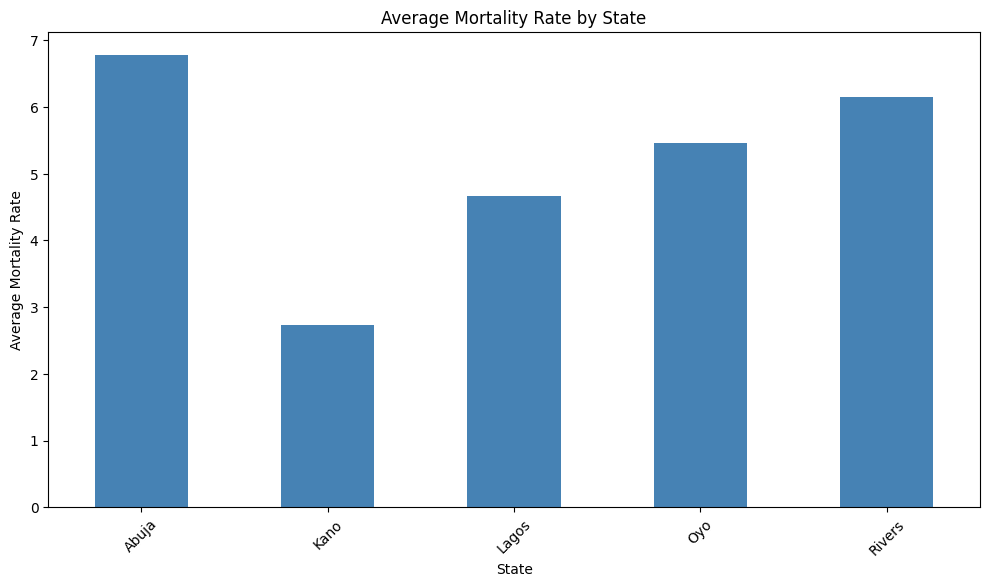

In [19]:
state_mortality = df.groupby("state")["mortality_rate"].mean()
plt.figure (figsize=(10,6))
state_mortality.plot(kind="bar", color="steelblue")
plt.title("Average Mortality Rate by State")
plt.xlabel("State")
plt.ylabel("Average Mortality Rate")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


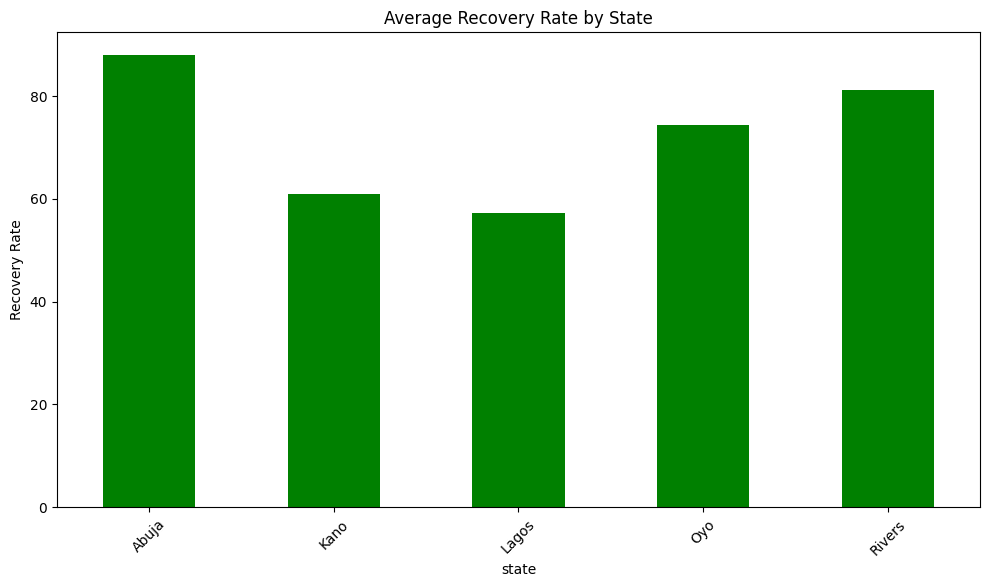

In [21]:
state_recovery = df.groupby("state")["recovery_rate"].mean()
plt.figure(figsize=(10,6))
state_recovery.plot(kind="bar", color="green")
plt.title("Average Recovery Rate by State")
plt.xlabel("state")
plt.ylabel("Recovery Rate")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
Summary

## Even though Kano had a low mortality rate, the state had the highest count of infections. This could be due to increased population, hygiene and overcrowdness in the North

##The monthly trend reveals that March 2023 recorded the highest count of Infection

## As much as a lot of Rainfall (in MM) was recorded in the past year, little of it  accounts for the rate of infection_count

## Lagos showed a significantly higher mortality rate than Kano (t=2.98, p=0.005), suggesting differences in healthcare access or case severity between the two states

Recommendation

## I'll recommend the implementation of targeted public health campaigns focusing on improved hygiene and sanitation practices in high-density areas
